# Module 5: Discrete Time Markov Chains

A Markov chain is a stochastic process in which the next state depends only on the current state, not on the full past history. This is called the Markov property.

In this module, we study Markov chains in discrete time. The process is written as

$$
X_0, X_1, X_2, \dots
$$

where $X_n$ is the state of the system at step $n$.

Markov chains appear in many applications, such as weather prediction, gambling, board games, PageRank, language models, and queueing systems.

Here we use finite state examples to study transition matrices, sample paths, state distributions, stationary distributions, absorbing states, and PageRank.

## Libraries




In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Circle

In [2]:
FIGSIZE = (8, 4.5)
SMALL_FIGSIZE = (8, 3.5)
SUBPLOT_FIGSIZE = (8, 9)

HIST_ALPHA = 0.65
OVERLAP_ALPHA = 0.45

plt.rcParams["figure.figsize"] = FIGSIZE
plt.rcParams["axes.grid"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["legend.frameon"] = False

plt.rcParams["lines.markersize"] = 4

## Motivation

The following page gives several examples of Markov chains in applications.

In this module, we only use small finite state examples. The purpose is to see how a Markov chain can be described by a transition matrix, simulated as a path, and studied through long run frequencies.

In [1]:
from IPython.display import IFrame

IFrame(
    src="https://en.wikipedia.org/wiki/Examples_of_Markov_chains",
    width="100%",
    height=500
)

## Model

Let $X_0,X_1,X_2,\dots$ be a discrete time Markov chain with finite state space

$$
E=\{0,1,\dots,m-1\}.
$$

The Markov property means that, once the current state is known, the distribution of the next state does not depend on the earlier history:

$$
P(X_{n+1}=j\mid X_0,\dots,X_n=i)
=
P(X_{n+1}=j\mid X_n=i).
$$

The transition probability from state $i$ to state $j$ is written as

$$
p_{ij}=P(X_{n+1}=j\mid X_n=i).
$$

All transition probabilities are collected in the transition matrix $P=(p_{ij})$. Row $i$ gives the probability distribution of the next state when the current state is $i$. Therefore each row must satisfy $p_{ij}\geq 0$ and $\sum_j p_{ij}=1$.

If the distribution of $X_n$ is written as a row vector

$$
p^{(n)}=(P(X_n=0),P(X_n=1),\dots,P(X_n=m-1)),
$$

then one step of the chain is computed by

$$
p^{(n+1)}=p^{(n)}P.
$$

Repeating this gives

$$
p^{(n)}=p^{(0)}P^n.
$$

### Helper functions

In [3]:
def simulate_markov_chain(P, x0, n_steps, rng):
    """
    Simulate one path of a finite discrete-time Markov chain.

    Parameters
    ----------
    P : numpy array
        Transition matrix.
    x0 : int
        Initial state.
    n_steps : int
        Number of transitions.
    rng : numpy.random.Generator
        Random number generator.

    Returns
    -------
    path : numpy array
        Simulated states from time 0 to time n_steps.
    """

    # Number of states
    n_states = P.shape[0]

    # Store the path
    path = np.zeros(n_steps + 1, dtype=int)

    # Initial state
    path[0] = x0

    # Simulate the chain
    for n in range(n_steps):
        current_state = path[n]

        path[n + 1] = rng.choice(
            n_states,
            p=P[current_state]
        )

    return path

In [4]:
def iterate_distribution(P, p0, n_steps):
    """
    Compute the distribution of a Markov chain over time.

    Parameters
    ----------
    P : numpy array
        Transition matrix.
    p0 : numpy array
        Initial distribution as a row vector.
    n_steps : int
        Number of time steps.

    Returns
    -------
    distributions : numpy array
        Row n contains the distribution at time n.
    """

    # Number of states
    n_states = P.shape[0]

    # Store distributions from time 0 to time n_steps
    distributions = np.zeros((n_steps + 1, n_states))

    # Initial distribution
    distributions[0] = p0

    # Iterate p^(n+1) = p^(n)P
    for n in range(n_steps):
        distributions[n + 1] = distributions[n] @ P

    return distributions

## Example 1: Weather prediction

We start with a simple weather model with two states:

$$
0=\text{sunny}, \qquad 1=\text{rainy}.
$$

Suppose the transition matrix is

$$
P=
\begin{pmatrix}
0.9 & 0.1\\
0.5 & 0.5
\end{pmatrix}.
$$

Rows describe the current state, and columns describe the next state. The first row says that if today is sunny, then tomorrow is sunny with probability $0.9$ and rainy with probability $0.1$. The second row says that if today is rainy, then tomorrow is sunny with probability $0.5$ and rainy with probability $0.5$.

In [5]:
# Transition matrix
P_weather = np.array([
    [0.9, 0.1],
    [0.5, 0.5]
])

# State labels
weather_labels = ["sunny", "rainy"]

print("Transition matrix:")
print(P_weather)

print("Row sums:")
print(P_weather.sum(axis=1))

Transition matrix:
[[0.9 0.1]
 [0.5 0.5]]
Row sums:
[1. 1.]


### Predicting the weather

Assume that today is sunny. Then the initial distribution is

$$
p^{(0)}=(1,0).
$$

To find the distribution after one day, multiply by the transition matrix:

$$
p^{(1)}
=
p^{(0)}P
=
(1,0)
\begin{pmatrix}
0.9 & 0.1\\
0.5 & 0.5
\end{pmatrix}
=
(0.9,0.1).
$$

This means that after one day, the probability of sunny weather is $0.9$, and the probability of rainy weather is $0.1$.

For two days, we multiply once more:

$$
p^{(2)}
=
p^{(1)}P
=
(0.9,0.1)
\begin{pmatrix}
0.9 & 0.1\\
0.5 & 0.5
\end{pmatrix}
=
(0.86,0.14).
$$

In general,

$$
p^{(n)}=p^{(0)}P^n.
$$

The code below repeats this calculation for several days.

In [6]:
# Initial distribution: sunny with probability 1
p0 = np.array([1.0, 0.0])

# Number of days
n_steps = 10

# Compute distributions
weather_distributions = iterate_distribution(P_weather, p0, n_steps)

# Print distributions
for n in range(n_steps + 1):
    print(
        f"day {n}: "
        f"P(sunny) = {weather_distributions[n, 0]:.4f}, "
        f"P(rainy) = {weather_distributions[n, 1]:.4f}"
    )

day 0: P(sunny) = 1.0000, P(rainy) = 0.0000
day 1: P(sunny) = 0.9000, P(rainy) = 0.1000
day 2: P(sunny) = 0.8600, P(rainy) = 0.1400
day 3: P(sunny) = 0.8440, P(rainy) = 0.1560
day 4: P(sunny) = 0.8376, P(rainy) = 0.1624
day 5: P(sunny) = 0.8350, P(rainy) = 0.1650
day 6: P(sunny) = 0.8340, P(rainy) = 0.1660
day 7: P(sunny) = 0.8336, P(rainy) = 0.1664
day 8: P(sunny) = 0.8334, P(rainy) = 0.1666
day 9: P(sunny) = 0.8334, P(rainy) = 0.1666
day 10: P(sunny) = 0.8334, P(rainy) = 0.1666


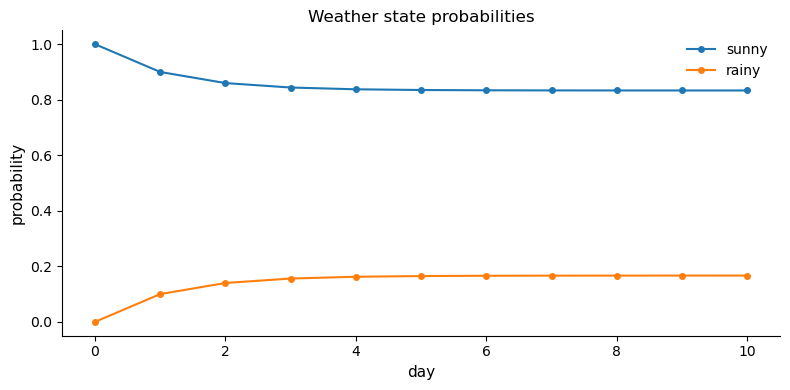

In [7]:
# Plot the predicted weather probabilities
plt.figure(figsize=(8, 4))

plt.plot(
    weather_distributions[:, 0],
    marker="o",
    label="sunny"
)

plt.plot(
    weather_distributions[:, 1],
    marker="o",
    label="rainy"
)

plt.xlabel("day")
plt.ylabel("probability")
plt.title("Weather state probabilities")
plt.legend()
plt.tight_layout()
plt.show()

This plot is not one simulated weather sequence. It shows the probability distribution of $X_n$ for each day $n$.

Starting from a sunny day, the probability of sunny weather decreases at first, while the probability of rainy weather increases. After several steps, the probabilities change more slowly.

## Example 2: From diagram to matrix

A finite state Markov chain can be represented by a transition diagram.

Each node is a state. Each arrow is a possible transition. The label on an arrow gives the transition probability.

The transition diagram and the transition matrix contain the same information. The diagram is easier to read visually, while the matrix is easier to use for computation.

In the transition matrix $P$, the entry $p_{ij}$ means

$$
p_{ij}=P(X_{n+1}=j\mid X_n=i).
$$

So row $i$ describes all possible next states when the current state is $i$.

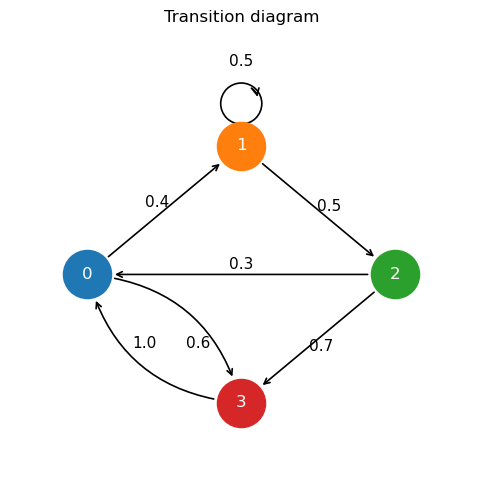

In [8]:
pos = {
    0: (0.0, 1.0),
    1: (1.2, 2.0),
    2: (2.4, 1.0),
    3: (1.2, 0.0),
}

edges = [
    (0, 1, "0.4"),
    (0, 3, "0.6"),
    (1, 2, "0.5"),
    (2, 0, "0.3"),
    (2, 3, "0.7"),
    (3, 0, "1.0"),
]

fig, ax = plt.subplots(figsize=(6, 5))

# Draw the states.
colors = {0: "#1f77b4", 1: "#ff7f0e", 2: "#2ca02c", 3: "#d62728"}
for state, (x, y) in pos.items():
    ax.scatter(x, y, s=1200, color=colors[state], zorder=3)
    ax.text(x, y, str(state), ha="center", va="center",
            color="white", fontsize=12, zorder=4)

def draw_arrow(i, j, label, rad=0.0, label_pos=0.5, dx=0.0, dy=0.0):
    x1, y1 = pos[i]
    x2, y2 = pos[j]

    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(
            arrowstyle="->",
            shrinkA=20,
            shrinkB=20,
            connectionstyle=f"arc3,rad={rad}",
            lw=1.2,
            color="black"
        ),
        zorder=2
    )

    xm = x1 + label_pos * (x2 - x1)
    ym = y1 + label_pos * (y2 - y1)
    ax.text(xm + dx, ym + dy, label, fontsize=11,
            ha="center", va="center", zorder=5)

# Draw the transitions between different states.
for i, j, label in edges:
    if (i, j) == (0, 3):
        draw_arrow(i, j, label, rad=-0.35, label_pos=0.57, dx=0.18, dy=0.03)
    elif (i, j) == (3, 0):
        draw_arrow(i, j, label, rad=-0.35, label_pos=0.43, dx=-0.24, dy=0.03)
    elif (i, j) == (0, 1):
        draw_arrow(i, j, label, label_pos=0.48, dx=-0.03, dy=0.08)
    elif (i, j) == (1, 2):
        draw_arrow(i, j, label, label_pos=0.52, dx=0.06, dy=0.05)
    elif (i, j) == (2, 0):
        draw_arrow(i, j, label, label_pos=0.50, dx=0.00, dy=0.08)
    elif (i, j) == (2, 3):
        draw_arrow(i, j, label, label_pos=0.53, dx=0.06, dy=-0.03)

# Draw the self transition at state 1.
x, y = pos[1]
loop_center = (x, y + 0.33)
loop_radius = 0.16

circle = Circle(loop_center, loop_radius, fill=False, lw=1.2, color="black", zorder=2)
ax.add_patch(circle)

arrow = FancyArrowPatch(
    (x + 0.06, y + 0.46),
    (x + 0.13, y + 0.36),
    arrowstyle="->",
    mutation_scale=12,
    lw=1.2,
    color="black",
    connectionstyle="arc3,rad=-0.3",
    zorder=3
)
ax.add_patch(arrow)

ax.text(x, y + 0.62, "0.5", fontsize=11, ha="center", zorder=5)

ax.set_xlim(-0.6, 3.0)
ax.set_ylim(-0.6, 2.9)
ax.set_aspect("equal")
ax.set_title("Transition diagram")
ax.axis("off")
plt.tight_layout()
plt.show()

From the transition diagram, we read one row of the matrix at a time.

From state $0$, the outgoing arrows go to state $1$ with probability $0.4$ and to state $3$ with probability $0.6$. Therefore row $0$ is

$$
(0,\;0.4,\;0,\;0.6).
$$

Doing the same for all states gives

$$
P=
\begin{pmatrix}
0 & 0.4 & 0 & 0.6\\
0 & 0.5 & 0.5 & 0\\
0.3 & 0 & 0 & 0.7\\
1 & 0 & 0 & 0
\end{pmatrix}.
$$

Each row is obtained from the outgoing arrows of one state. If there is no arrow from state $i$ to state $j$, then the matrix entry $p_{ij}$ is $0$.

In [9]:
# Transition matrix read from the diagram
P_diagram = np.array([
    [0.0, 0.4, 0.0, 0.6],
    [0.0, 0.5, 0.5, 0.0],
    [0.3, 0.0, 0.0, 0.7],
    [1.0, 0.0, 0.0, 0.0]
])

print("Transition matrix:")
print(P_diagram)

print("Row sums:")
print(P_diagram.sum(axis=1))

Transition matrix:
[[0.  0.4 0.  0.6]
 [0.  0.5 0.5 0. ]
 [0.3 0.  0.  0.7]
 [1.  0.  0.  0. ]]
Row sums:
[1. 1. 1. 1.]


The row sums are all equal to $1$, so every row is a probability distribution over the next state.

This is the matrix form of the transition diagram above.

### Task 1: From a larger transition diagram to a matrix

Now consider a Markov chain with state space

$$
S=\{0,1,2,3,4,5,6,7\}.
$$

Read the transition probabilities from the diagram below and write down the transition matrix $P$ in the state order

$$
0,1,2,3,4,5,6,7.
$$

After constructing the matrix, check that each row sums to $1$.


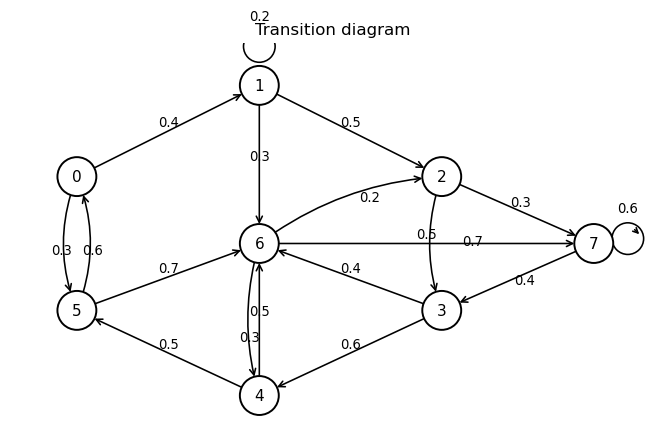

In [10]:
# Positions of the states
pos = {
    0: (0.0, 1.55),
    1: (1.5, 2.30),
    2: (3.0, 1.55),
    3: (3.0, 0.45),
    4: (1.5, -0.25),
    5: (0.0, 0.45),
    6: (1.5, 1.00),
    7: (4.25, 1.00),
}

# Directed edges: from state, to state, transition probability.
edges = [
    (0, 1, "0.4"),
    (0, 5, "0.6"),

    (1, 2, "0.5"),
    (1, 6, "0.3"),
    (1, 1, "0.2"),

    (2, 3, "0.7"),
    (2, 7, "0.3"),

    (3, 4, "0.6"),
    (3, 6, "0.4"),

    (4, 5, "0.5"),
    (4, 6, "0.5"),

    (5, 0, "0.3"),
    (5, 6, "0.7"),

    (6, 2, "0.2"),
    (6, 4, "0.3"),
    (6, 7, "0.5"),

    (7, 3, "0.4"),
    (7, 7, "0.6"),
]

fig, ax = plt.subplots(figsize=FIGSIZE)

# Draw states
for state, (x, y) in pos.items():
    circle = Circle(
        (x, y),
        0.16,
        color="white",
        ec="black",
        lw=1.4,
        zorder=3
    )
    ax.add_patch(circle)

    ax.text(
        x,
        y,
        str(state),
        ha="center",
        va="center",
        fontsize=11,
        zorder=4
    )

def draw_arrow(i, j, label, rad=0.0, label_pos=0.5, dx=0.0, dy=0.0):
    """Draw a directed edge with a probability label."""
    x1, y1 = pos[i]
    x2, y2 = pos[j]

    arrow = FancyArrowPatch(
        (x1, y1),
        (x2, y2),
        arrowstyle="->",
        mutation_scale=11,
        lw=1.15,
        color="black",
        connectionstyle=f"arc3,rad={rad}",
        shrinkA=14,
        shrinkB=14,
        zorder=2
    )
    ax.add_patch(arrow)

    xm = x1 + label_pos * (x2 - x1)
    ym = y1 + label_pos * (y2 - y1)

    ax.text(
        xm + dx,
        ym + dy,
        label,
        fontsize=9.5,
        ha="center",
        va="center",
        zorder=5
    )

def draw_self_loop(state, label, dx=0.0, dy=0.32):
    """Draw a self-loop near a state."""
    x, y = pos[state]

    loop = Circle(
        (x + dx, y + dy),
        0.13,
        fill=False,
        ec="black",
        lw=1.15,
        zorder=2
    )
    ax.add_patch(loop)

    arrow = FancyArrowPatch(
        (x + dx + 0.04, y + dy + 0.09),
        (x + dx + 0.11, y + dy + 0.02),
        arrowstyle="->",
        mutation_scale=9,
        lw=1.15,
        color="black",
        zorder=3
    )
    ax.add_patch(arrow)

    ax.text(
        x + dx,
        y + dy + 0.25,
        label,
        fontsize=9.5,
        ha="center",
        va="center",
        zorder=5
    )

# Draw arrows
for i, j, label in edges:
    if i == j:
        if i == 1:
            draw_self_loop(i, label, dx=0.0, dy=0.32)
        elif i == 7:
            draw_self_loop(i, label, dx=0.28, dy=0.04)
    else:
        if (i, j) == (5, 0):
            draw_arrow(i, j, label, rad=0.20, label_pos=0.45, dx=-0.13, dy=0.00)
        elif (i, j) == (0, 5):
            draw_arrow(i, j, label, rad=0.20, label_pos=0.55, dx=0.13, dy=0.00)
        elif (i, j) == (2, 3):
            draw_arrow(i, j, label, rad=0.18, label_pos=0.50, dx=0.25, dy=0.02)
        elif (i, j) == (6, 2):
            draw_arrow(i, j, label, rad=-0.15, label_pos=0.55, dx=0.08, dy=0.08)
        elif (i, j) == (6, 4):
            draw_arrow(i, j, label, rad=0.15, label_pos=0.55, dx=-0.08, dy=-0.08)
        elif (i, j) == (7, 3):
            draw_arrow(i, j, label, rad=0.0, label_pos=0.55, dx=0.12, dy=0.00)
        elif (i, j) == (2, 7):
            draw_arrow(i, j, label, rad=0.0, label_pos=0.52, dx=0.00, dy=0.08)
        elif (i, j) == (6, 7):
            draw_arrow(i, j, label, rad=0.0, label_pos=0.50, dx=0.00, dy=0.08)
        else:
            draw_arrow(i, j, label, rad=0.0, label_pos=0.5, dx=0.00, dy=0.07)

ax.set_xlim(-0.55, 4.75)
ax.set_ylim(-0.55, 2.65)
ax.set_aspect("equal", adjustable="box")
ax.set_title("Transition diagram")
ax.axis("off")

plt.tight_layout()
plt.show()

Write your answer here:

$$
P=
\begin{pmatrix}
\cdots & \cdots & \cdots & \cdots & \cdots & \cdots & \cdots & \cdots\\
\cdots & \cdots & \cdots & \cdots & \cdots & \cdots & \cdots & \cdots\\
\cdots & \cdots & \cdots & \cdots & \cdots & \cdots & \cdots & \cdots\\
\cdots & \cdots & \cdots & \cdots & \cdots & \cdots & \cdots & \cdots\\
\cdots & \cdots & \cdots & \cdots & \cdots & \cdots & \cdots & \cdots\\
\cdots & \cdots & \cdots & \cdots & \cdots & \cdots & \cdots & \cdots\\
\cdots & \cdots & \cdots & \cdots & \cdots & \cdots & \cdots & \cdots\\
\cdots & \cdots & \cdots & \cdots & \cdots & \cdots & \cdots & \cdots
\end{pmatrix}.
$$

Use the code cell below to enter the matrix and test the row sums.


In [11]:
# Enter the transition matrix read from the diagram.
# The zeros below are placeholders for the task.
# Each row must sum to 1.
P_task_8 = np.array([
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
])

print("Transition matrix:")
print(P_task_8)

print("Row sums:")
print(P_task_8.sum(axis=1))

Transition matrix:
[[0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]]
Row sums:
[0. 0. 0. 0. 0. 0. 0. 0.]


### Solution

From the diagram, each row of the transition matrix is obtained by reading the outgoing arrows from one state.

Using the state order

$$
0,1,2,3,4,5,6,7,
$$

we get

$$
P=
\begin{pmatrix}
0 & 0.4 & 0 & 0 & 0 & 0.6 & 0 & 0\\
0 & 0.2 & 0.5 & 0 & 0 & 0 & 0.3 & 0\\
0 & 0 & 0 & 0.7 & 0 & 0 & 0 & 0.3\\
0 & 0 & 0 & 0 & 0.6 & 0 & 0.4 & 0\\
0 & 0 & 0 & 0 & 0 & 0.5 & 0.5 & 0\\
0.3 & 0 & 0 & 0 & 0 & 0 & 0.7 & 0\\
0 & 0 & 0.2 & 0 & 0.3 & 0 & 0 & 0.5\\
0 & 0 & 0 & 0.4 & 0 & 0 & 0.6 & 0
\end{pmatrix}.
$$

The zeros mean that the corresponding arrows are not present in the diagram.

In [12]:
# Solution matrix for the 8-state task
P_task_8_solution = np.array([
    [0.0, 0.4, 0.0, 0.0, 0.0, 0.6, 0.0, 0.0],
    [0.0, 0.2, 0.5, 0.0, 0.0, 0.0, 0.3, 0.0],
    [0.0, 0.0, 0.0, 0.7, 0.0, 0.0, 0.0, 0.3],
    [0.0, 0.0, 0.0, 0.0, 0.6, 0.0, 0.4, 0.0],
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 0.5, 0.0],
    [0.3, 0.0, 0.0, 0.0, 0.0, 0.0, 0.7, 0.0],
    [0.0, 0.0, 0.2, 0.0, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.0, 0.0, 0.4, 0.0, 0.0, 0.0, 0.6]
])

print("Transition matrix:")
print(P_task_8_solution)

print("Row sums:")
print(P_task_8_solution.sum(axis=1))

Transition matrix:
[[0.  0.4 0.  0.  0.  0.6 0.  0. ]
 [0.  0.2 0.5 0.  0.  0.  0.3 0. ]
 [0.  0.  0.  0.7 0.  0.  0.  0.3]
 [0.  0.  0.  0.  0.6 0.  0.4 0. ]
 [0.  0.  0.  0.  0.  0.5 0.5 0. ]
 [0.3 0.  0.  0.  0.  0.  0.7 0. ]
 [0.  0.  0.2 0.  0.3 0.  0.  0.5]
 [0.  0.  0.  0.4 0.  0.  0.  0.6]]
Row sums:
[1. 1. 1. 1. 1. 1. 1. 1.]


This example shows two equivalent ways to represent the same Markov chain.

The transition diagram is useful for seeing how the states are connected. The transition matrix is useful for computation, simulation, and multiplying distributions such as $p^{(n)}=p^{(0)}P^n$.

## Example 3: Simulating a Markov chain path

In Task 1, we constructed the transition matrix `P_task_8_solution` from the 8-state transition diagram.

We now use this matrix to simulate one possible path of the Markov chain. This shows how the matrix is not only a static description of the chain, but also a rule for generating random movement between states.

A sample path is one possible realization:

$$
X_0,X_1,X_2,\dots,X_n.
$$

At each step, the current state determines which row of $P$ is used. The next state is then sampled according to the probabilities in that row.

In [13]:
# Use the transition matrix constructed from the 8-state diagram
P_sim = P_task_8_solution.copy()

# Initial state
x0 = 0

# Number of steps
n_steps = 100

# Random generator
rng = np.random.default_rng()

# Simulate one path
path = simulate_markov_chain(P_sim, x0, n_steps, rng)

print("Simulated path:")
print(path)

Simulated path:
[0 5 6 4 6 7 3 4 5 6 7 3 4 5 6 7 3 4 6 2 3 4 5 6 4 5 6 2 3 4 6 7 3 6 4 5 0
 5 0 1 6 7 3 4 6 7 7 7 3 4 6 4 6 7 7 7 3 4 5 6 7 7 7 3 4 5 6 4 5 6 4 5 6 2
 3 6 4 5 6 7 3 4 6 7 3 4 6 7 7 7 3 6 4 5 6 7 3 4 5 6 4]


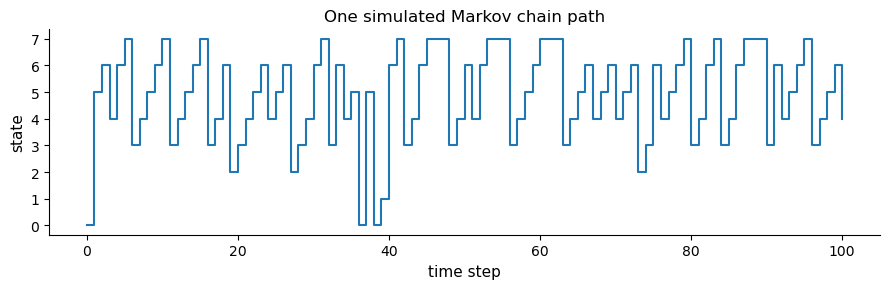

In [14]:
# Plot one simulated path
plt.figure(figsize=(9, 3))

plt.step(
    np.arange(n_steps + 1),
    path,
    where="post"
)

plt.yticks(range(P_sim.shape[0]))
plt.xlabel("time step")
plt.ylabel("state")
plt.title("One simulated Markov chain path")
plt.tight_layout()
plt.show()

The plot shows one simulated path of the Markov chain defined by `P_task_8_solution`.

This is one realization, not a probability distribution. At each time step the chain is in exactly one state. If the simulation is run again, the path may look different, even though the transition matrix is unchanged.

In [15]:
# Empirical frequency of each state in this path
counts = np.bincount(path, minlength=P_sim.shape[0])
frequencies = counts / len(path)

print("State   count   frequency")
for state in range(P_sim.shape[0]):
    print(f"{state:5d}   {counts[state]:5d}   {frequencies[state]:.3f}")

State   count   frequency
    0       3   0.030
    1       1   0.010
    2       3   0.030
    3      15   0.149
    4      21   0.208
    5      14   0.139
    6      24   0.238
    7      20   0.198


The frequencies count how often each state appears in this single simulated path.

For a short path, these frequencies can be quite random. In the next example, we use a much longer path and compare the empirical frequencies with the stationary distribution.

## Example 4: Stationary distribution

A stationary distribution is a probability vector $\pi$ that does not change after one transition.

It satisfies

$$
\pi P=\pi.
$$

This means that if the Markov chain starts with distribution $\pi$, then after one step it still has distribution $\pi$.

We also need the normalization condition

$$
\sum_i \pi_i=1.
$$

For a finite Markov chain, the stationary distribution can often describe the long-run proportion of time spent in each state.

In this example, we use the same transition matrix as in Example 3. We compare the stationary distribution with empirical frequencies from one long simulated path.

In [16]:
def stationary_distribution(P):
    """
    Compute a stationary distribution of a finite Markov chain.

    Parameters
    ----------
    P : numpy array
        Transition matrix.

    Returns
    -------
    pi : numpy array
        Stationary distribution.
    """

    # Number of states
    n_states = P.shape[0]

    # Solve pi P = pi together with the normalization condition.
    A = P.T - np.eye(n_states)

    # Replace one equation by the normalization condition sum(pi) = 1
    A[-1, :] = np.ones(n_states)

    # Right-hand side
    b = np.zeros(n_states)
    b[-1] = 1

    # Solve the linear system
    pi = np.linalg.solve(A, b)

    return pi

In [17]:
# Compute the stationary distribution
pi = stationary_distribution(P_sim)

# Simulate a longer path
n_steps_long = 10000
x0 = 0

rng = np.random.default_rng()

long_path = simulate_markov_chain(
    P_sim,
    x0,
    n_steps_long,
    rng
)

# Empirical frequencies
long_counts = np.bincount(long_path, minlength=P_sim.shape[0])
long_frequencies = long_counts / len(long_path)

# Print comparison
print("State   empirical frequency   stationary probability")
for state in range(P_sim.shape[0]):
    print(
        f"{state:5d}   "
        f"{long_frequencies[state]:.4f}                "
        f"{pi[state]:.4f}"
    )

State   empirical frequency   stationary probability
    0   0.0302                0.0283
    1   0.0141                0.0141
    2   0.0493                0.0488
    3   0.1527                0.1533
    4   0.1573                0.1546
    5   0.0992                0.0943
    6   0.2070                0.2089
    7   0.2903                0.2977


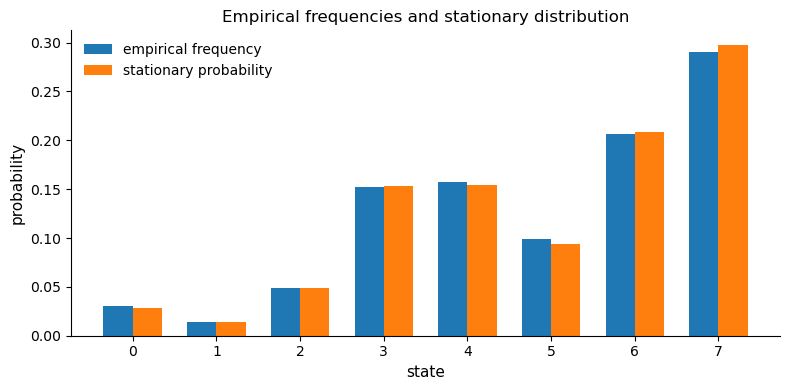

In [18]:
# Compare empirical frequencies and stationary distribution
states = np.arange(P_sim.shape[0])
width = 0.35

plt.figure(figsize=(8, 4))

plt.bar(
    states - width / 2,
    long_frequencies,
    width,
    label="empirical frequency"
)

plt.bar(
    states + width / 2,
    pi,
    width,
    label="stationary probability"
)

plt.xlabel("state")
plt.ylabel("probability")
plt.title("Empirical frequencies and stationary distribution")
plt.xticks(states)
plt.legend()
plt.tight_layout()
plt.show()

The bars compare empirical frequencies from one long simulated path with the stationary distribution computed from $\pi P=\pi$. For this example, the two sets of bars are close, which suggests that the long path spends roughly the expected proportion of time in each state.

A stationary distribution does not always describe the long run behaviour of every starting state. For example, absorbing chains need separate interpretation. In the examples below, absorption is treated directly by recording the final absorbing state and the absorption time.


## Example 5: Gambler's ruin as an absorbing Markov chain

We have already studied gambler's ruin in the random walk module. There, the focus was on sample paths and on estimating the probability of reaching a target fortune before ruin.

Here we revisit the same problem from the Markov chain point of view. The gambler's current wealth is treated as the state of the chain. The game continues until the wealth reaches either $0$ or a fixed target level $r$.

This example shows how a familiar random walk problem can be represented by a transition matrix with absorbing states. We will simulate several paths to see the randomness of the outcome, and then repeat the simulation many times to estimate ruin and success probabilities.

Suppose a gambler starts with $i$ units of wealth. At each step, the gambler wins one unit with probability $p$ and loses one unit with probability $q=1-p$.

The game stops when the wealth reaches either $0$ or $r$. The state space is

$$
S=\{0,1,2,\dots,r\}.
$$

The boundary states are absorbing:

$$
P_{00}=1,\qquad P_{rr}=1.
$$

State $0$ means ruin, and state $r$ means reaching the target wealth. For each interior state $1\leq i\leq r-1$, the chain moves to $i+1$ with probability $p$ and to $i-1$ with probability $q$.

In [19]:
def gambler_ruin_matrix(r, p):
    """
    Construct the transition matrix for the gambler's ruin Markov chain.

    Parameters
    ----------
    r : int
        Target wealth. The states are 0, 1, ..., r.
    p : float
        Probability of winning one unit.

    Returns
    -------
    P : numpy array
        Transition matrix.
    """

    # Losing probability
    q = 1 - p

    # Number of states: 0, 1, ..., r
    n_states = r + 1

    # Create transition matrix filled with zeros
    P = np.zeros((n_states, n_states))

    # State 0 is absorbing
    P[0, 0] = 1.0

    # State r is absorbing
    P[r, r] = 1.0

    # Interior states
    for i in range(1, r):
        P[i, i + 1] = p
        P[i, i - 1] = q

    return P


def simulate_until_absorption(P, x0, absorbing_states, rng):
    """
    Simulate a Markov chain path until it reaches an absorbing state.

    Parameters
    ----------
    P : numpy array
        Transition matrix.
    x0 : int
        Initial state.
    absorbing_states : list
        Absorbing states.
    rng : numpy.random.Generator
        Random number generator.

    Returns
    -------
    path : numpy array
        Simulated path until absorption.
    """

    # Number of states
    n_states = P.shape[0]

    # Store the path
    path = [x0]

    # Initial state
    current_state = x0

    # Continue until the chain reaches an absorbing state
    while current_state not in absorbing_states:

        # Choose the next state according to the current row of P
        next_state = rng.choice(
            n_states,
            p=P[current_state]
        )

        # Save the next state
        path.append(next_state)

        # Update current state
        current_state = next_state

    return np.array(path)

In [20]:
# Target wealth
r = 20

# Winning probability
p = 0.5

# Initial wealth
x0 = 10

# Absorbing states
absorbing_states = [0, r]

# Transition matrix
P_gambler = gambler_ruin_matrix(r, p)

print("Transition matrix shape:", P_gambler.shape)
print("Row sums:")
print(P_gambler.sum(axis=1))

Transition matrix shape: (21, 21)
Row sums:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [21]:
# Simulate three paths to show different possible outcomes
n_paths = 3

# Random generator
rng = np.random.default_rng()

gambler_paths = []

for path_id in range(n_paths):
    path = simulate_until_absorption(
        P_gambler,
        x0,
        absorbing_states,
        rng
    )

    gambler_paths.append(path)

    outcome = "success" if path[-1] == r else "ruin"

    print(
        f"path {path_id + 1}: "
        f"outcome = {outcome}, "
        f"absorption time = {len(path) - 1}, "
        f"final wealth = {path[-1]}"
    )

path 1: outcome = success, absorption time = 104, final wealth = 20
path 2: outcome = ruin, absorption time = 54, final wealth = 0
path 3: outcome = ruin, absorption time = 122, final wealth = 0


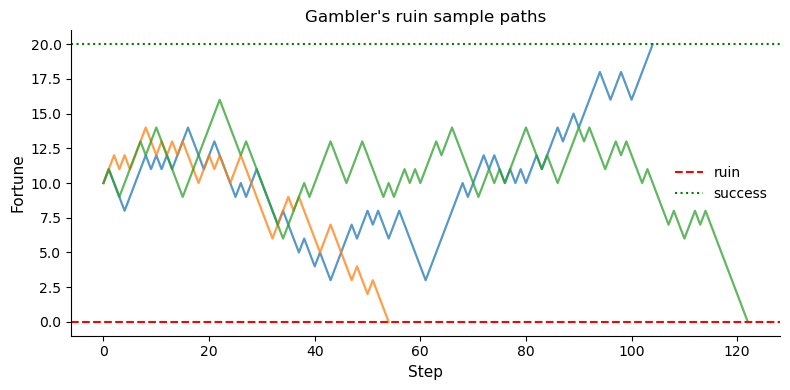

In [22]:
# Plot the three simulated paths
plt.figure(figsize=(8, 4))

for path_id, path in enumerate(gambler_paths):
    plt.plot(
        np.arange(len(path)),
        path,
        alpha=0.75,
        linewidth=1.6,
    )

plt.axhline(0, linestyle="--", color="red", label="ruin")
plt.axhline(r, linestyle=":", color="green", label="success")

plt.xlabel("Step")
plt.ylabel("Fortune")
plt.title("Gambler's ruin sample paths")
plt.legend()
plt.tight_layout()
plt.show()

Compared with the random walk module, the main difference here is the representation. The same boundary hitting problem is now encoded directly in a transition matrix with two absorbing states.

### Repeated simulations

A few paths show possible outcomes, but they do not estimate the probabilities accurately. To study the absorbing chain more systematically, we repeat the experiment many times.

For each run, we record the final absorbing state $X_\tau$ and the absorption time

$$
\tau=\min\{n\geq 0:X_n=0 \text{ or } X_n=r\}.
$$

Here, $X_\tau$ tells us whether the game ended in ruin or at the target wealth. The value of $\tau$ tells us how long the game lasted.

In [23]:
# Number of repeated simulations
n_runs = 5000

# Store final states and absorption times
final_states = np.zeros(n_runs, dtype=int)
absorption_times = np.zeros(n_runs, dtype=int)

# Random generator
rng = np.random.default_rng()

for run in range(n_runs):
    path = simulate_until_absorption(
        P_gambler,
        x0,
        absorbing_states,
        rng
    )

    final_states[run] = path[-1]
    absorption_times[run] = len(path) - 1

# Estimate probabilities
prob_ruin = np.mean(final_states == 0)
prob_target = np.mean(final_states == r)

print("Estimated probability of ruin:", prob_ruin)
print("Estimated probability of reaching target:", prob_target)
print("Sum of estimated probabilities:", prob_ruin + prob_target)
print("Mean absorption time:", np.mean(absorption_times))

Estimated probability of ruin: 0.4966
Estimated probability of reaching target: 0.5034
Sum of estimated probabilities: 1.0
Mean absorption time: 101.7576


For the fair case $p=0.5$, the theoretical probability of reaching the target before ruin is

$$
P(X_\tau=r)=\frac{x_0}{r}.
$$

Therefore,

$$
P(X_\tau=0)=1-\frac{x_0}{r}.
$$

This is the same formula used in the random walk module. Here it is interpreted through the absorbing Markov chain representation.

In [24]:
# Theoretical hitting probabilities for the fair case
theoretical_prob_target = x0 / r
theoretical_prob_ruin = 1 - theoretical_prob_target

print("Theoretical probability of reaching target:", theoretical_prob_target)
print("Theoretical probability of ruin:", theoretical_prob_ruin)

Theoretical probability of reaching target: 0.5
Theoretical probability of ruin: 0.5


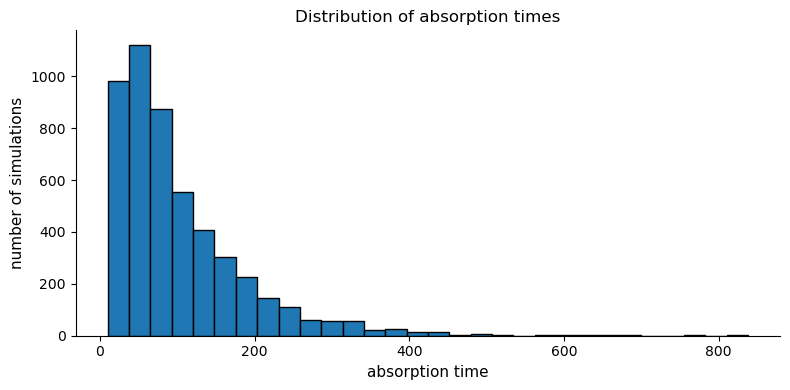

In [25]:
# Plot the distribution of absorption times
plt.figure(figsize=(8, 4))

plt.hist(
    absorption_times,
    bins=30,
    edgecolor="black"
)

plt.xlabel("absorption time")
plt.ylabel("number of simulations")
plt.title("Distribution of absorption times")
plt.tight_layout()
plt.show()

The histogram shows the distribution of absorption times over many simulations. Some games end quickly, while others last much longer. Thus both the final absorbing state $X_\tau$ and the absorption time $\tau$ are random quantities. This example moves from individual paths to repeated simulation of an absorbing Markov chain.


## Example 6: A simplified Google PageRank model

PageRank is an application of finite state Markov chains. It was introduced to rank webpages by using the link structure of the web.

In this simplified model, the states are webpages. A random surfer moves from page to page by following links, but sometimes jumps randomly to another page. The PageRank score of a page is the long-run proportion of time that the random surfer spends on that page.

The real ranking problem is much larger and more complex. Here we only use a small four-page web to illustrate the Markov chain idea.

Suppose the pages are

$$
0=\text{Search},\qquad
1=\text{News},\qquad
2=\text{University},\qquad
3=\text{Blog}.
$$

The directed links are

$$
0\to 1,\quad 0\to 2,\qquad
1\to 2,\qquad
2\to 0,\qquad
3\to 0,\quad 3\to 2.
$$

If a page has several outgoing links, the surfer chooses uniformly among them. We first visualize the web graph and then construct the link transition matrix $H$.

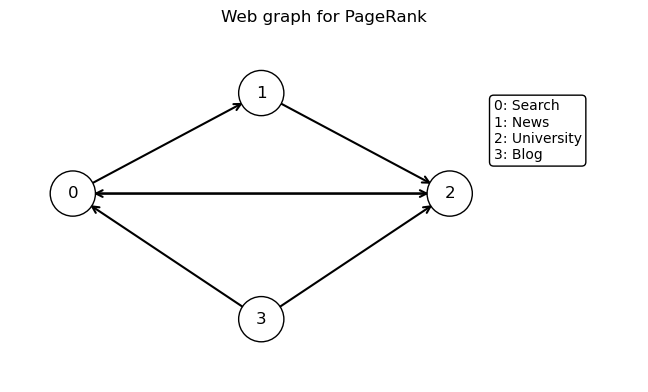

In [26]:
# Draw the web graph used in the PageRank example.

page_names = ["Search", "News", "University", "Blog"]

page_positions = {
    0: (0.0, 1.0),
    1: (1.5, 1.8),
    2: (3.0, 1.0),
    3: (1.5, 0.0)
}

web_edges = [
    (0, 1),
    (0, 2),
    (1, 2),
    (2, 0),
    (3, 0),
    (3, 2)
]

fig, ax = plt.subplots(figsize=(7, 4))

# Draw nodes
for page, (x, y) in page_positions.items():
    circle = Circle((x, y), 0.18, color="white", ec="black", zorder=3)
    ax.add_patch(circle)
    ax.text(x, y, str(page), ha="center", va="center", fontsize=12, zorder=4)

# Draw directed edges
for start, end in web_edges:
    x1, y1 = page_positions[start]
    x2, y2 = page_positions[end]

    arrow = FancyArrowPatch(
        (x1, y1),
        (x2, y2),
        arrowstyle="->",
        mutation_scale=12,
        linewidth=1.5,
        shrinkA=15,
        shrinkB=15
    )
    ax.add_patch(arrow)

# Add page names.
label_text = "\n".join(
    [f"{i}: {name}" for i, name in enumerate(page_names)]
)

ax.text(
    3.35,
    1.75,
    label_text,
    ha="left",
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="black")
)

ax.set_xlim(-0.5, 4.5)
ax.set_ylim(-0.5, 2.3)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("Web graph for PageRank")
plt.tight_layout()
plt.show()

The graph shows the link structure of the four webpages.

Each page is a state of the Markov chain. Each directed edge is a hyperlink. The link transition matrix $H$ is obtained by reading the outgoing arrows from each page.

For example, the page Search links to News and University. Therefore, from state $0$, the surfer moves to state $1$ with probability $1/2$ and to state $2$ with probability $1/2$.

In [27]:
# Number of webpages
n_pages = 4

# Page labels
page_names = ["Search", "News", "University", "Blog"]

# Link transition matrix
# Rows are current pages, columns are next pages.
H = np.array([
    [0.0, 0.5, 0.5, 0.0],   # Search links to News and University
    [0.0, 0.0, 1.0, 0.0],   # News links to University
    [1.0, 0.0, 0.0, 0.0],   # University links to Search
    [0.5, 0.0, 0.5, 0.0]    # Blog links to Search and University
])

print("Page labels:")
for i, name in enumerate(page_names):
    print(f"{i}: {name}")

print()
print("Link transition matrix H:")
print(H)

print()
print("Row sums:")
print(H.sum(axis=1))

Page labels:
0: Search
1: News
2: University
3: Blog

Link transition matrix H:
[[0.  0.5 0.5 0. ]
 [0.  0.  1.  0. ]
 [1.  0.  0.  0. ]
 [0.5 0.  0.5 0. ]]

Row sums:
[1. 1. 1. 1.]


The matrix $H$ only describes movement by following links. PageRank also includes random jumping, so that the surfer does not get trapped in a small part of the graph.

Let $d$ be the probability of following a link. Then $1-d$ is the probability of jumping randomly to any page.

The PageRank transition matrix is

$$
P=dH+(1-d)\frac{1}{n}\mathbf{1},
$$

where $n$ is the number of pages and $\mathbf{1}$ is the matrix whose entries are all equal to $1$.

In the code below we use $d=0.85$. This is a common value for the random surfer model.

In [28]:
# Damping factor
d = 0.85

# Matrix with all entries equal to 1/n_pages
random_jump = np.ones((n_pages, n_pages)) / n_pages

# PageRank transition matrix
P_pagerank = d * H + (1 - d) * random_jump

print("PageRank transition matrix P:")
print(P_pagerank)

print()
print("Row sums:")
print(P_pagerank.sum(axis=1))

PageRank transition matrix P:
[[0.0375 0.4625 0.4625 0.0375]
 [0.0375 0.0375 0.8875 0.0375]
 [0.8875 0.0375 0.0375 0.0375]
 [0.4625 0.0375 0.4625 0.0375]]

Row sums:
[1. 1. 1. 1.]


### Simulating one random surfer path

Before computing the PageRank scores, we simulate one possible path of the random surfer. At each step, the current page determines which row of the PageRank transition matrix is used. The next page is sampled according to the probabilities in that row.


In [29]:
# Simulate one short random surfer path
x0 = 0
n_steps_path = 100

rng = np.random.default_rng()

surfer_path_short = simulate_markov_chain(
    P_pagerank,
    x0,
    n_steps_path,
    rng
)

print("One random surfer path:")
print(surfer_path_short)

One random surfer path:
[0 1 0 1 2 0 2 0 2 0 1 2 0 1 2 0 2 0 2 0 3 2 0 2 0 1 2 0 1 2 1 2 0 1 2 0 2
 0 1 2 0 2 0 2 0 2 0 1 1 2 0 2 0 2 0 1 2 0 2 0 2 0 0 2 0 1 2 0 1 2 0 2 0 3
 1 2 0 3 0 1 2 0 2 2 0 2 0 2 0 2 0 2 0 0 2 0 1 1 2 0 1]


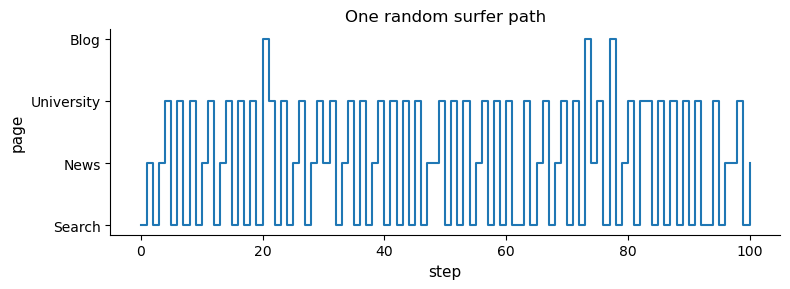

In [30]:
# Plot one random surfer path
plt.figure(figsize=(8, 3))

plt.step(
    np.arange(n_steps_path + 1),
    surfer_path_short,
    where="post"
)

plt.xlabel("step")
plt.ylabel("page")
plt.title("One random surfer path")
plt.yticks(range(n_pages), page_names)
plt.tight_layout()
plt.show()

The plot shows one possible sequence of webpages visited by the random surfer. This is one realization, not the PageRank score itself. If the simulation is run again, the visited pages may appear in a different order.

### PageRank scores

The PageRank scores are given by the stationary distribution $\pi$ satisfying

$$
\pi P=\pi.
$$

The larger $\pi_i$ is, the more often the random surfer visits page $i$ in the long run. In this simplified model, a larger long-run probability means a higher rank.

In [31]:
# Compute PageRank scores as the stationary distribution
pagerank_scores = stationary_distribution(P_pagerank)

print("PageRank scores:")
for page in range(n_pages):
    print(f"{page_names[page]:10s}: {pagerank_scores[page]:.4f}")

print()
print("Ranking from highest to lowest:")
ranking = np.argsort(-pagerank_scores)

for rank, page in enumerate(ranking, start=1):
    print(f"{rank}: {page_names[page]}")

PageRank scores:
Search    : 0.3797
News      : 0.1989
University: 0.3839
Blog      : 0.0375

Ranking from highest to lowest:
1: University
2: Search
3: News
4: Blog


In [32]:
# Simulate a long random surfer path
x0 = 0
n_steps_long = 10000

rng = np.random.default_rng()

surfer_path = simulate_markov_chain(
    P_pagerank,
    x0,
    n_steps_long,
    rng
)

# Empirical frequencies from the long path
surfer_counts = np.bincount(surfer_path, minlength=n_pages)
surfer_frequencies = surfer_counts / len(surfer_path)

print("Page         empirical frequency   PageRank score")
for page in range(n_pages):
    print(
        f"{page_names[page]:10s}   "
        f"{surfer_frequencies[page]:.4f}                "
        f"{pagerank_scores[page]:.4f}"
    )

Page         empirical frequency   PageRank score
Search       0.3777                0.3797
News         0.1999                0.1989
University   0.3861                0.3839
Blog         0.0364                0.0375


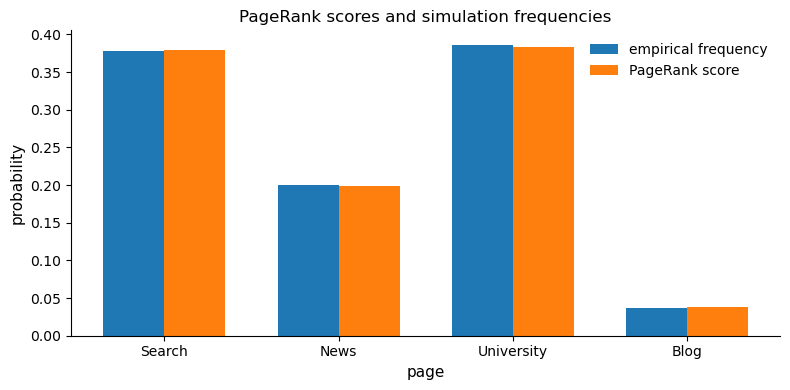

In [33]:
# Compare empirical frequencies with PageRank scores
x = np.arange(n_pages)
width = 0.35

plt.figure(figsize=(8, 4))

plt.bar(
    x - width / 2,
    surfer_frequencies,
    width,
    label="empirical frequency"
)

plt.bar(
    x + width / 2,
    pagerank_scores,
    width,
    label="PageRank score"
)

plt.xlabel("page")
plt.ylabel("probability")
plt.title("PageRank scores and simulation frequencies")
plt.xticks(x, page_names)
plt.legend()
plt.tight_layout()
plt.show()

The short path shows one possible movement of the random surfer through the small web graph. The empirical frequencies are obtained from one long simulation. The PageRank scores are obtained by solving the stationary equation $\pi P=\pi$. When the simulated path is long, the empirical frequencies should be close to the PageRank scores.
